# The Mood Map of Music 🎵

## Project Overview

Music can be described through several audio characteristics, including energy, danceability, and valence. This project uses data visualization to explore how these characteristics vary across Spotify tracks and genres, and how they relate to track popularity.

Rather than assuming that a particular type of music is more popular, the analysis investigates patterns in the dataset through visual exploration and summary statistics.

## Objectives

* Explore the distribution of track popularity.
* Visualize tracks using energy and valence to create a four-zone mood map.
* Compare audio characteristics across selected genres.
* Investigate relationships between audio features and popularity.
* Communicate findings through clear, well-designed visualizations.

## Tools Used

Python, Pandas, NumPy, Matplotlib, Seaborn, and Google Colab.

## Research Questions

1. How are tracks distributed across the four energy–valence zones?
2. How does average popularity vary across these zones?
3. How do musical characteristics differ across genres?
4. What relationships exist between selected audio features and popularity?

## Approach

The analysis begins with data inspection and cleaning, followed by exploratory visualizations, group comparisons, and correlation analysis. Conclusions are based on the observed results and are limited to the available dataset.


In [ ]:

from google.colab import files

uploaded = files.upload()

Saving spotify-tracks-dataset-detailed.csv to spotify-tracks-dataset-detailed.csv


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Use a consistent style for our visualizations
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)

# Find the uploaded CSV file
csv_files = list(uploaded.keys())
csv_files = [f for f in csv_files if f.lower().endswith(".csv")]

if not csv_files:
    raise ValueError("Please upload a CSV dataset file.")

file_path = csv_files[0]
df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("File:", file_path)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully!
File: spotify-tracks-dataset-detailed.csv
Rows: 114000
Columns: 20


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## 1. Understanding the Dataset

The dataset contains Spotify tracks along with their metadata and audio characteristics. Before creating visualizations, I will examine its structure, data types, missing values, and duplicate records. This initial inspection will help identify any data-quality issues that could affect the analysis.


In [ ]:

# Preview sample records
display(df.head(10))

# Inspect column names and data types
print("\nDATASET INFORMATION")
df.info()

# Check missing values
print("\nMISSING VALUES")
missing = df.isnull().sum().sort_values(ascending=False)
display(missing[missing > 0])

# Check duplicate records
print("\nDUPLICATE ROWS")
print("Number of duplicate rows:", df.duplicated().sum())

# View descriptive statistics for numerical columns
print("\nNUMERICAL SUMMARY")
display(df.describe().T.round(2))

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
5,01MVOl9KtVTNfFiBU9I7dc,Tyrone Wells,Days I Will Remember,Days I Will Remember,58,214240,False,0.688,0.4810,6,-8.807,1,0.1050,0.2890,0.000000,0.1890,0.6660,98.017,4,acoustic
6,6Vc5wAMmXdKIAM7WUoEb7N,A Great Big World;Christina Aguilera,Is There Anybody Out There?,Say Something,74,229400,False,0.407,0.1470,2,-8.822,1,0.0355,0.8570,0.000003,0.0913,0.0765,141.284,3,acoustic
7,1EzrEOXmMH3G43AXT1y7pA,Jason Mraz,We Sing. We Dance. We Steal Things.,I'm Yours,80,242946,False,0.703,0.4440,11,-9.331,1,0.0417,0.5590,0.000000,0.0973,0.7120,150.960,4,acoustic
8,0IktbUcnAGrvD03AWnz3Q8,Jason Mraz;Colbie Caillat,We Sing. We Dance. We Steal Things.,Lucky,74,189613,False,0.625,0.4140,0,-8.700,1,0.0369,0.2940,0.000000,0.1510,0.6690,130.088,4,acoustic
9,7k9GuJYLp2AzqokyEdwEw2,Ross Copperman,Hunger,Hunger,56,205594,False,0.442,0.6320,1,-6.770,1,0.0295,0.4260,0.004190,0.0735,0.1960,78.899,4,acoustic



DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16 

,0
artists,1
album_name,1
track_name,1



DUPLICATE ROWS
Number of duplicate rows: 450

NUMERICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
popularity,114000.0,33.24,22.31,0.00,17.00,35.00,50.00,100.00
duration_ms,114000.0,228029.15,107297.71,0.00,174066.00,212906.00,261506.00,5237295.00
danceability,114000.0,0.57,0.17,0.00,0.46,0.58,0.70,0.98
energy,114000.0,0.64,0.25,0.00,0.47,0.68,0.85,1.00
key,114000.0,5.31,3.56,0.00,2.00,5.00,8.00,11.00
loudness,114000.0,-8.26,5.03,-49.53,-10.01,-7.00,-5.00,4.53
mode,114000.0,0.64,0.48,0.00,0.00,1.00,1.00,1.00
speechiness,114000.0,0.08,0.11,0.00,0.04,0.05,0.08,0.96
acousticness,114000.0,0.31,0.33,0.00,0.02,0.17,0.60,1.00
instrumentalness,114000.0,0.16,0.31,0.00,0.00,0.00,0.05,1.00


In [ ]:

# Check which expected columns are available
expected_columns = [
    "track_name",
    "artists",
    "track_genre",
    "popularity",
    "danceability",
    "energy",
    "valence",
    "acousticness",
    "instrumentalness",
    "tempo",
    "duration_ms"
]

available_columns = [col for col in expected_columns if col in df.columns]
missing_columns = [col for col in expected_columns if col not in df.columns]

print("Available project columns:")
print(available_columns)

if missing_columns:
    print("\nColumns not found in this dataset version:")
    print(missing_columns)

required_columns = [
    "popularity", "danceability", "energy", "valence"
]

if not all(col in df.columns for col in required_columns):
    raise ValueError(
        "The uploaded dataset does not contain all required core columns. "
        "Check the dataset version before continuing."
    )

# Create a working copy for the analysis
music = df.copy()

print("\nWorking dataset shape:", music.shape)

Available project columns:
['track_name', 'artists', 'track_genre', 'popularity', 'danceability', 'energy', 'valence', 'acousticness', 'instrumentalness', 'tempo', 'duration_ms']

Working dataset shape: (114000, 20)


## 2. Exploring Track Popularity

Popularity scores provide a starting point for understanding the tracks in the dataset. I will visualize their distribution to examine how frequently different popularity levels occur. This will help establish context before comparing popularity with musical characteristics.


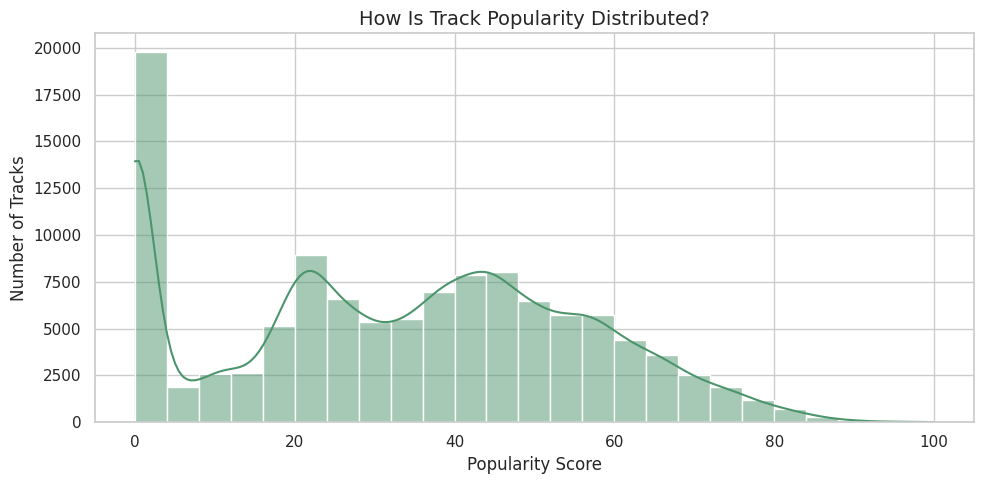

Mean popularity: 33.24
Median popularity: 35.0


In [ ]:

plt.figure(figsize=(10, 5))

sns.histplot(
    data=music,
    x="popularity",
    bins=25,
    kde=True,
    color="#4C956C"
)

plt.title("How Is Track Popularity Distributed?", fontsize=14)
plt.xlabel("Popularity Score")
plt.ylabel("Number of Tracks")
plt.tight_layout()

plt.savefig("01_popularity_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print("Mean popularity:", round(music["popularity"].mean(), 2))
print("Median popularity:", round(music["popularity"].median(), 2))

## 3. Mapping the Mood of Music

Energy and valence describe different aspects of a track's audio characteristics. Energy represents the intensity and activity of the music, while valence describes its musical positivity. I will use these two features to create a mood map and investigate how tracks are distributed across different combinations of energy and valence.


In [ ]:

# Keep rows with valid values for the main analysis
music["energy"] = pd.to_numeric(music["energy"], errors="coerce")
music["valence"] = pd.to_numeric(music["valence"], errors="coerce")
music["popularity"] = pd.to_numeric(music["popularity"], errors="coerce")

mood_data = music.dropna(
    subset=["energy", "valence", "popularity"]
).copy()

# Keep valid energy and valence values
mood_data = mood_data[
    mood_data["energy"].between(0, 1)
    & mood_data["valence"].between(0, 1)
].copy()

# Assign tracks to four descriptive mood quadrants
mood_data["mood_zone"] = np.select(
    [
        (mood_data["energy"] >= 0.5) & (mood_data["valence"] >= 0.5),
        (mood_data["energy"] >= 0.5) & (mood_data["valence"] < 0.5),
        (mood_data["energy"] < 0.5) & (mood_data["valence"] >= 0.5),
        (mood_data["energy"] < 0.5) & (mood_data["valence"] < 0.5)
    ],
    [
        "Energetic & Positive",
        "Energetic & Darker",
        "Calm & Positive",
        "Calm & Melancholic"
    ],
    default="Unclassified"
)

print("Rows in original dataset:", len(music))
print("Rows in mood analysis:", len(mood_data))
print("\nTracks in each mood zone:")
display(
    mood_data["mood_zone"]
    .value_counts()
    .rename_axis("Mood Zone")
    .to_frame("Track Count")
)

Rows in original dataset: 114000
Rows in mood analysis: 114000

Tracks in each mood zone:


,Track Count
Mood Zone,
Energetic & Positive,43405
Energetic & Darker,38761
Calm & Melancholic,23086
Calm & Positive,8748


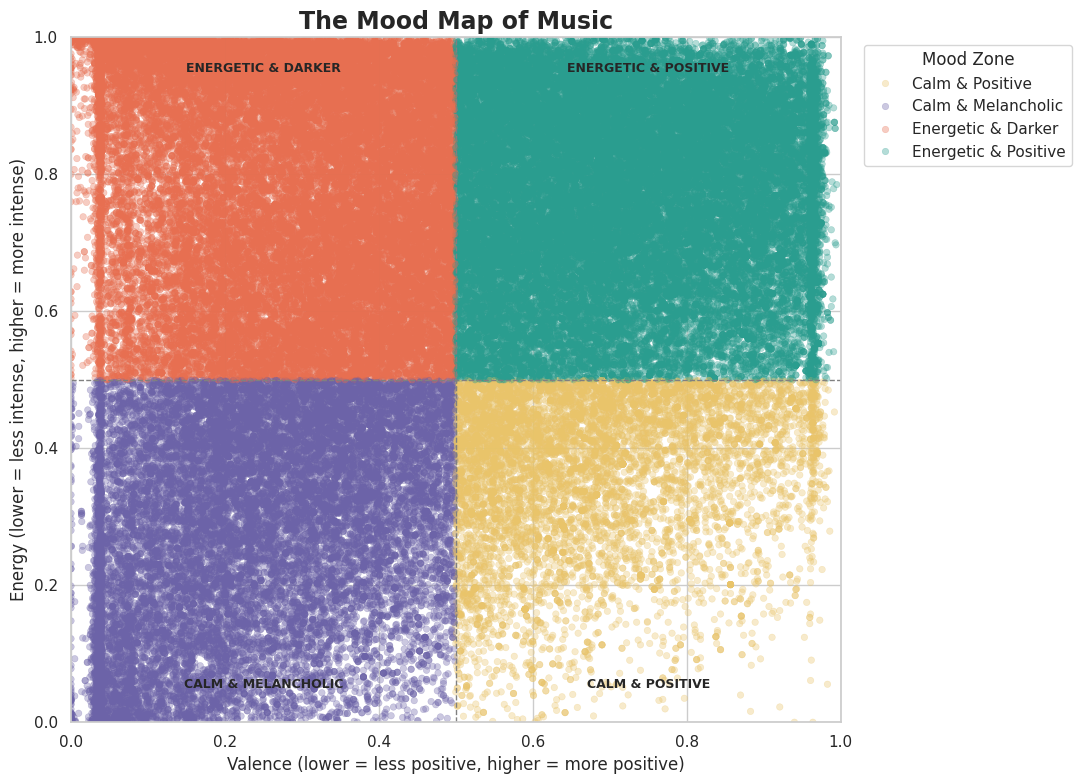

In [ ]:

plt.figure(figsize=(11, 8))

sns.scatterplot(
    data=mood_data,
    x="valence",
    y="energy",
    hue="mood_zone",
    alpha=0.35,
    s=22,
    palette={
        "Energetic & Positive": "#2A9D8F",
        "Energetic & Darker": "#E76F51",
        "Calm & Positive": "#E9C46A",
        "Calm & Melancholic": "#6C63A8"
    },
    edgecolor=None
)

plt.axvline(0.5, color="gray", linestyle="--", linewidth=1)
plt.axhline(0.5, color="gray", linestyle="--", linewidth=1)

plt.text(0.75, 0.95, "ENERGETIC & POSITIVE",
         ha="center", fontsize=9, weight="bold")
plt.text(0.25, 0.95, "ENERGETIC & DARKER",
         ha="center", fontsize=9, weight="bold")
plt.text(0.75, 0.05, "CALM & POSITIVE",
         ha="center", fontsize=9, weight="bold")
plt.text(0.25, 0.05, "CALM & MELANCHOLIC",
         ha="center", fontsize=9, weight="bold")

plt.title("The Mood Map of Music", fontsize=17, weight="bold")
plt.xlabel("Valence (lower = less positive, higher = more positive)")
plt.ylabel("Energy (lower = less intense, higher = more intense)")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(title="Mood Zone", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

plt.savefig("02_mood_map.png", dpi=300, bbox_inches="tight")
plt.show()

,track_count,average_popularity,median_popularity,average_energy,average_valence
mood_zone,,,,,
Energetic & Darker,38761,34.50,36.0,0.77,0.29
Calm & Melancholic,23086,33.72,37.0,0.28,0.24
Energetic & Positive,43405,32.49,34.0,0.77,0.72
Calm & Positive,8748,30.08,28.0,0.37,0.68


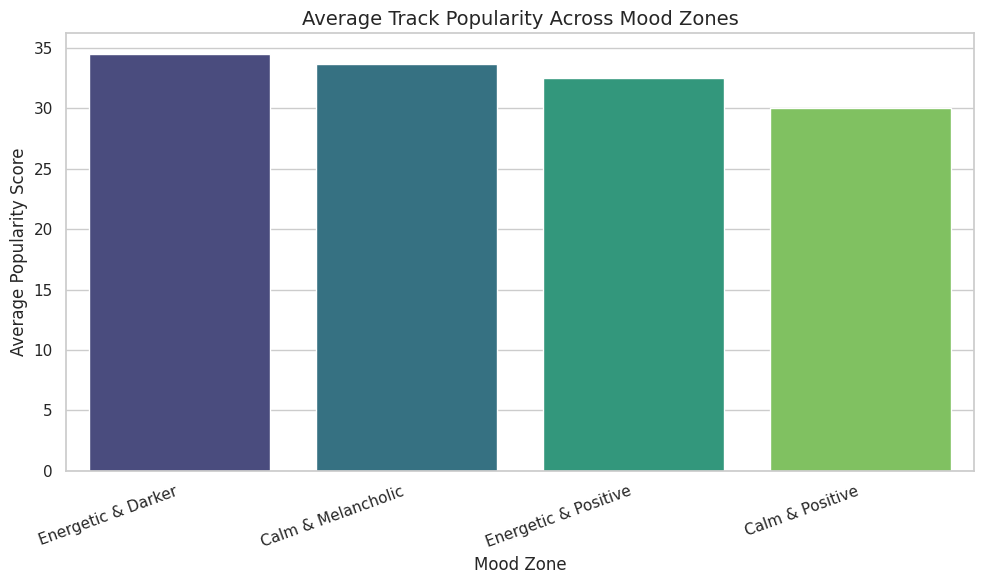

In [ ]:

mood_summary = (
    mood_data.groupby("mood_zone")
    .agg(
        track_count=("popularity", "size"),
        average_popularity=("popularity", "mean"),
        median_popularity=("popularity", "median"),
        average_energy=("energy", "mean"),
        average_valence=("valence", "mean")
    )
    .sort_values("average_popularity", ascending=False)
    .round(2)
)

display(mood_summary)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=mood_summary.reset_index(),
    x="mood_zone",
    y="average_popularity",
    hue="mood_zone",
    legend=False,
    palette="viridis"
)

plt.title("Average Track Popularity Across Mood Zones", fontsize=14)
plt.xlabel("Mood Zone")
plt.ylabel("Average Popularity Score")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

plt.savefig("03_popularity_by_mood.png", dpi=300, bbox_inches="tight")
plt.show()

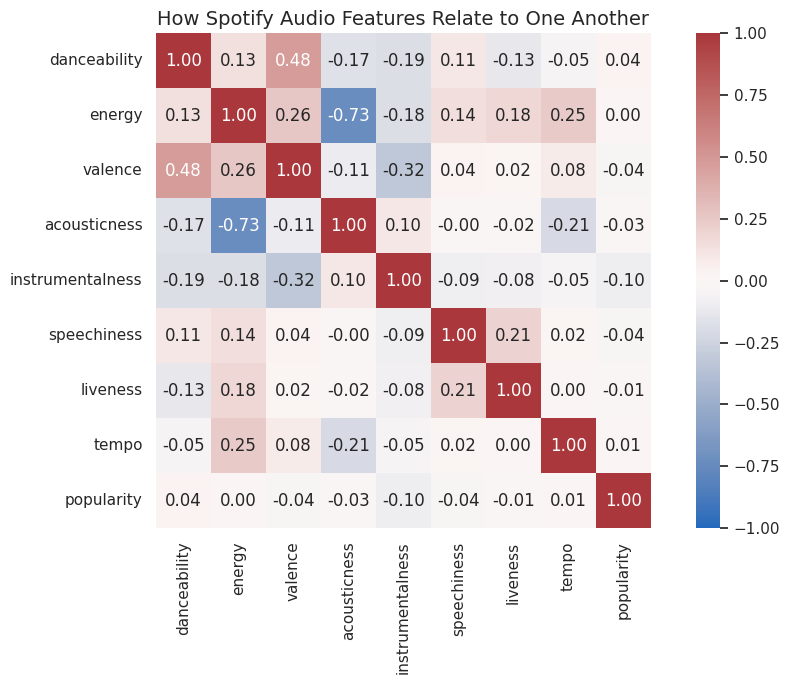

In [ ]:

candidate_features = [
    "danceability",
    "energy",
    "valence",
    "acousticness",
    "instrumentalness",
    "speechiness",
    "liveness",
    "tempo",
    "popularity"
]

features = [
    col for col in candidate_features
    if col in music.columns
]

feature_data = music[features].apply(
    pd.to_numeric, errors="coerce"
)

correlation = feature_data.corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation,
    annot=True,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    fmt=".2f",
    square=True
)

plt.title("How Spotify Audio Features Relate to One Another", fontsize=14)
plt.tight_layout()
plt.savefig("04_audio_feature_correlations.png", dpi=300, bbox_inches="tight")
plt.show()

## 4. Initial Findings

* **Mood distribution:** The mood map shows how tracks are distributed across combinations of energy and valence.
* **Popularity comparison:** The mood-zone summary allows us to compare average and median popularity rather than relying on visual impressions alone.
* **Audio relationships:** The correlation heatmap helps identify relationships between audio features that deserve further investigation.
* **Limitations:** These results describe the dataset being analyzed. They do not establish that a particular mood causes popularity, and the dataset may not represent every song or listener.

*I will update these observations with specific numerical findings after reviewing the generated charts and summary tables.*


## 5. How Musical Characteristics Differ by Genre

Music genres can differ in their typical sound and audio characteristics. In this section, I will compare energy, danceability, and valence across genres to identify patterns and differences in the dataset. I will also consider the number of tracks available for each genre so that the comparisons are interpreted in context.


In [ ]:

# Check whether genre information is available
if "track_genre" not in music.columns:
    raise ValueError(
        "The dataset does not contain 'track_genre'. "
        "Check the column names before continuing."
    )

genre_data = music.copy()

for col in ["energy", "danceability", "valence", "popularity"]:
    if col in genre_data.columns:
        genre_data[col] = pd.to_numeric(
            genre_data[col], errors="coerce"
        )

# Select the 12 genres with the most records
top_genres = genre_data["track_genre"].value_counts().head(12).index

genre_subset = genre_data[
    genre_data["track_genre"].isin(top_genres)
].copy()

# Summarize the characteristics of each genre
genre_summary = (
    genre_subset.groupby("track_genre")
    .agg(
        track_count=("track_genre", "size"),
        avg_energy=("energy", "mean"),
        avg_danceability=("danceability", "mean"),
        avg_valence=("valence", "mean"),
        avg_popularity=("popularity", "mean")
    )
    .sort_values("avg_danceability", ascending=False)
    .round(3)
)

display(genre_summary)

,track_count,avg_energy,avg_danceability,avg_valence,avg_popularity
track_genre,,,,,
afrobeat,1000,0.703,0.670,0.699,24.399
breakbeat,1000,0.853,0.646,0.475,20.123
blues,1000,0.582,0.569,0.604,31.188
brazil,1000,0.621,0.563,0.470,44.670
alternative,1000,0.720,0.560,0.496,24.337
acoustic,1000,0.435,0.550,0.424,42.483
anime,1000,0.674,0.537,0.434,48.772
bluegrass,1000,0.530,0.535,0.635,25.676
alt-rock,1000,0.754,0.534,0.518,33.943


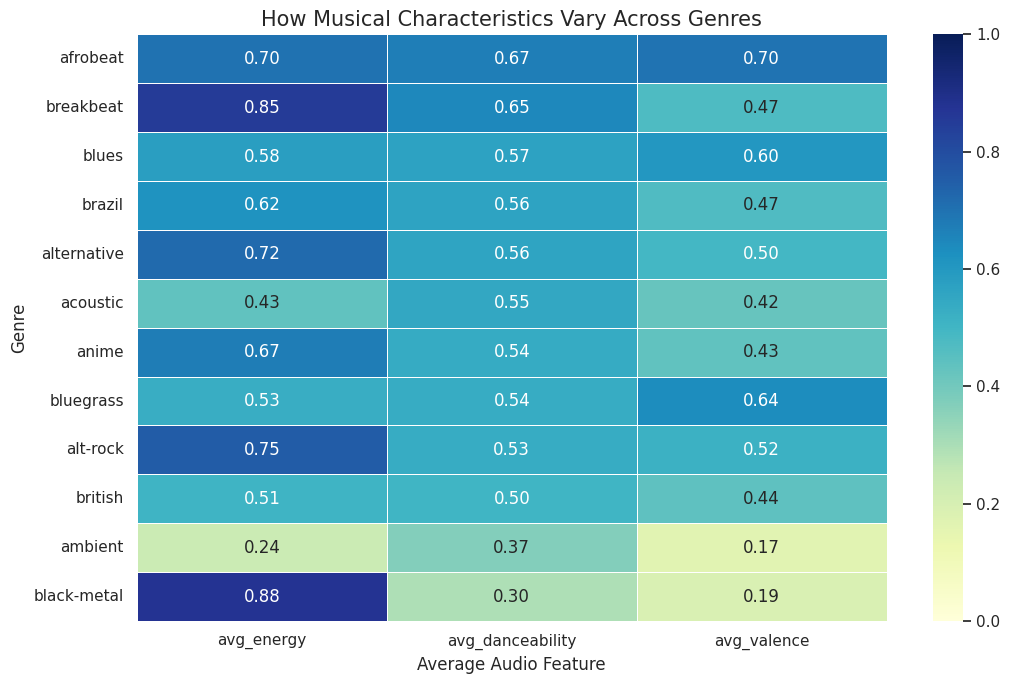

In [ ]:

genre_features = [
    "avg_energy",
    "avg_danceability",
    "avg_valence"
]

genre_heatmap = genre_summary[genre_features].dropna()

plt.figure(figsize=(11, 7))

sns.heatmap(
    genre_heatmap,
    annot=True,
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    fmt=".2f",
    linewidths=0.5
)

plt.title("How Musical Characteristics Vary Across Genres", fontsize=15)
plt.xlabel("Average Audio Feature")
plt.ylabel("Genre")
plt.tight_layout()

plt.savefig("05_genre_characteristics.png", dpi=300, bbox_inches="tight")
plt.show()

,track_count,mean_popularity,median_popularity
track_genre,,,
anime,1000,48.77,50.0
brazil,1000,44.67,45.0
ambient,1000,44.19,50.0
british,1000,43.80,52.0
acoustic,1000,42.48,47.0
alt-rock,1000,33.94,45.0
blues,1000,31.19,34.0
bluegrass,1000,25.68,24.0
afrobeat,1000,24.40,21.0


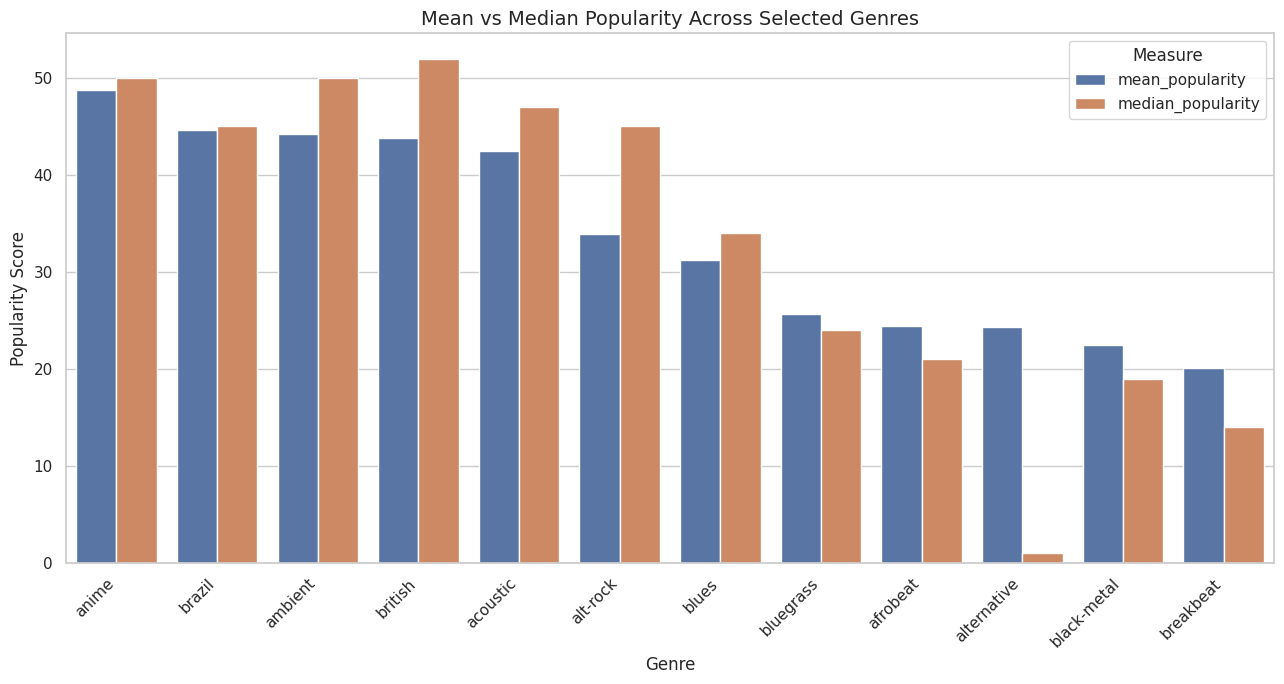

In [ ]:

popularity_by_genre = (
    genre_subset.groupby("track_genre")
    .agg(
        track_count=("popularity", "count"),
        mean_popularity=("popularity", "mean"),
        median_popularity=("popularity", "median")
    )
    .sort_values("mean_popularity", ascending=False)
    .round(2)
)

display(popularity_by_genre)

plot_data = popularity_by_genre.reset_index().melt(
    id_vars="track_genre",
    value_vars=["mean_popularity", "median_popularity"],
    var_name="measure",
    value_name="popularity"
)

plt.figure(figsize=(13, 7))

sns.barplot(
    data=plot_data,
    x="track_genre",
    y="popularity",
    hue="measure"
)

plt.title("Mean vs Median Popularity Across Selected Genres", fontsize=14)
plt.xlabel("Genre")
plt.ylabel("Popularity Score")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Measure")
plt.tight_layout()

plt.savefig("06_genre_popularity_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

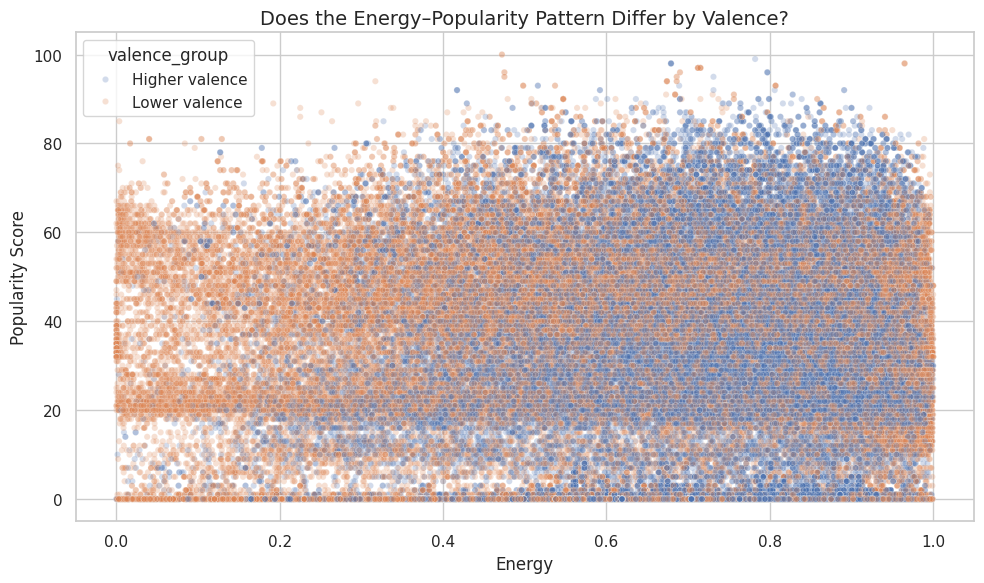

Correlation between energy and popularity by valence group:


,0
valence_group,
Higher valence,0.028
Lower valence,-0.000


In [ ]:

# Create two groups based on the median valence
valence_cutoff = mood_data["valence"].median()

mood_data["valence_group"] = np.where(
    mood_data["valence"] >= valence_cutoff,
    "Higher valence",
    "Lower valence"
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=mood_data,
    x="energy",
    y="popularity",
    hue="valence_group",
    alpha=0.25,
    s=20
)

plt.title("Does the Energy–Popularity Pattern Differ by Valence?", fontsize=14)
plt.xlabel("Energy")
plt.ylabel("Popularity Score")
plt.tight_layout()

plt.savefig("07_energy_popularity_by_valence.png", dpi=300, bbox_inches="tight")
plt.show()

# Calculate correlations separately for each group
energy_popularity_corr = (
    mood_data.groupby("valence_group")
    .apply(
        lambda group: group["energy"].corr(group["popularity"]),
        include_groups=False
    )
)

print("Correlation between energy and popularity by valence group:")
display(energy_popularity_corr.round(3))

In [ ]:

print("=" * 55)
print("THE MOOD MAP OF MUSIC — FINDINGS")
print("=" * 55)

print("\n1. MOOD DISTRIBUTION")
display(
    mood_data["mood_zone"]
    .value_counts()
    .rename_axis("Mood zone")
    .to_frame("Track count")
)

print("\n2. POPULARITY BY MOOD")
display(
    mood_summary[
        ["track_count", "average_popularity", "median_popularity"]
    ].sort_values("average_popularity", ascending=False)
)

print("\n3. GENRE WITH HIGHEST AVERAGE DANCEABILITY")
dance_row = genre_summary["avg_danceability"].idxmax()
print(dance_row, ":", genre_summary.loc[dance_row, "avg_danceability"])

print("\n4. GENRE WITH HIGHEST AVERAGE ENERGY")
energy_row = genre_summary["avg_energy"].idxmax()
print(energy_row, ":", genre_summary.loc[energy_row, "avg_energy"])

print("\n5. GENRE WITH HIGHEST AVERAGE VALENCE")
valence_row = genre_summary["avg_valence"].idxmax()
print(valence_row, ":", genre_summary.loc[valence_row, "avg_valence"])

print("\n6. ENERGY–POPULARITY CORRELATION BY VALENCE GROUP")
display(energy_popularity_corr.round(3))

THE MOOD MAP OF MUSIC — FINDINGS

1. MOOD DISTRIBUTION


,Track count
Mood zone,
Energetic & Positive,43405
Energetic & Darker,38761
Calm & Melancholic,23086
Calm & Positive,8748



2. POPULARITY BY MOOD


,track_count,average_popularity,median_popularity
mood_zone,,,
Energetic & Darker,38761,34.50,36.0
Calm & Melancholic,23086,33.72,37.0
Energetic & Positive,43405,32.49,34.0
Calm & Positive,8748,30.08,28.0



3. GENRE WITH HIGHEST AVERAGE DANCEABILITY
afrobeat : 0.67

4. GENRE WITH HIGHEST AVERAGE ENERGY
black-metal : 0.875

5. GENRE WITH HIGHEST AVERAGE VALENCE
afrobeat : 0.699

6. ENERGY–POPULARITY CORRELATION BY VALENCE GROUP


,0
valence_group,
Higher valence,0.028
Lower valence,-0.000


## 6. What the Data Reveals

**Mood distribution:** The largest mood zone in this dataset was Energetic & Darker, with 38761 tracks.

**Genre differences:** Among the 12 genres selected for comparison, afrobeat had the highest average danceability, while black-metal had the highest average energy.

**Popularity patterns:** The comparison of mean and median popularity showed that the median was higher than the mean for several genres, suggesting that some less-popular tracks may have lowered the average. In other genres, the mean was higher than the median, indicating that a few more-popular tracks may have increased the average. The analysis of energy and popularity also indicated a weak relationship, suggesting that a song's energy level alone does not strongly determine its popularity.


**Limitations:** This is an exploratory analysis of the available Spotify dataset. The selected genres, track coverage, popularity scores, and data collection period affect the results. Audio features cannot fully capture the personal experience of listening to music, and correlation does not establish causation.


In [ ]:

from pathlib import Path
from zipfile import ZipFile, ZIP_DEFLATED
from google.colab import files

# Collect charts created during the analysis
chart_files = sorted(Path(".").glob("*.png"))

if not chart_files:
    print("No PNG charts found. Run the visualization cells first.")
else:
    zip_name = "Mood_Map_Visualizations.zip"

    with ZipFile(zip_name, "w", ZIP_DEFLATED) as zip_file:
        for chart in chart_files:
            zip_file.write(chart, arcname=chart.name)

    print("Charts included:")
    for chart in chart_files:
        print("-", chart.name)

    files.download(zip_name)

Charts included:
- 01_popularity_distribution.png
- 02_mood_map.png
- 03_popularity_by_mood.png
- 04_audio_feature_correlations.png
- 05_genre_characteristics.png
- 06_genre_popularity_comparison.png
- 07_energy_popularity_by_valence.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>